# Processing stackSentinel over CA

In [8]:
import os
#os.environ["OMP_NUM_THREADS"] = "4" # export OMP_NUM_THREADS=4
#os.environ["OPENBLAS_NUM_THREADS"] = "1" # export OPENBLAS_NUM_THREADS=4 
#os.environ["MKL_NUM_THREADS"] = "6" # export MKL_NUM_THREADS=6
#os.environ["VECLIB_MAXIMUM_THREADS"] = "4" # export VECLIB_MAXIMUM_THREADS=4
#os.environ["NUMEXPR_NUM_THREADS"] = "6" # export NUMEXPR_NUM_THREADS=6

In [9]:
import site
from pathlib import Path
import subprocess
import numpy as np
import time
import zipfile

import requests
from lxml import etree
import urllib.request
from urllib.parse import urljoin

import rasterio
from rasterio import logging
log = logging.getLogger()
log.setLevel(logging.ERROR)

import pandas as pd
import geopandas as gpd
from shapely.geometry import box
from shapely import Polygon

# Plotting modules
from IPython import display
from cartopy import crs as ccrs
from matplotlib import pyplot as plt
import cartopy.io.img_tiles as cimgt

# isce2
import isce
isce_application_path = Path(isce.isce_path) / 'applications'
os.environ['PATH'] += (':' + str(isce_application_path))

# TopsStack aux modules
import asf_search as asf
import eof 
from dem_stitcher.stitcher import stitch_dem

In [ ]:
# Additional functions
def make_geodataframe(asf_search_object):
    df = pd.DataFrame(asf_search_object.properties, dtype=str, index=[0])
    df['wkt'] = Polygon(asf_search_object.geometry['coordinates'][0]).wkt
    gs = gpd.GeoSeries.from_wkt(df['wkt'])
    gdf = gpd.GeoDataFrame(df, geometry=gs, crs="EPSG:4326")
    return gdf

def tag_dem_xml_as_ellipsoidal(dem_path: Path) -> str:
    xml_path = str(dem_path) + '.xml'
    assert(Path(xml_path).exists())
    tree = etree.parse(xml_path)
    root = tree.getroot()

    y = etree.Element("property", name='reference')
    etree.SubElement(y, "value").text = "WGS84"
    etree.SubElement(y, "doc").text = "Geodetic datum"

    root.insert(0, y)
    with open(xml_path, 'wb') as file:
        file.write(etree.tostring(root, pretty_print=True))
    return xml_path


def fix_image_xml(isce_raster_path: str) -> str:
    isce_application_path = Path(f'{site.getsitepackages()[0]}'
                                '/isce/applications/')

    fix_cmd = [f'{isce_application_path}/fixImageXml.py',
               '-i',
               str(isce_raster_path),
               '--full']
    fix_cmd_line = ' '.join(fix_cmd)
    subprocess.check_call(fix_cmd_line, shell=True)
    print(fix_cmd_line)
    return isce_raster_path

# DEM = Digital Elevation Model
def download_dem_for_isce2(extent: list,
                           dem_name: str = 'glo_30',
                           dem_dir: Path = None,
                           dem_res = 0.0002777777777777777775,
                           buffer: float = .004) -> dict:
    """
    Parameters
    ----------
    extent : list
        [xmin, ymin, xmax, ymin] for epsg:4326 (i.e. (x, y) = (lon, lat))
    dem_name : str, optional
        See names in `dem_stitcher`
    dem_dir: Path, optional
        
    buffer : float, optional
        In degrees, by default .001, which is .5 km at equator
    Returns
    -------
    Path
    """
    dem_dir = dem_dir or Path(f'{dem_name}')
    dem_dir.mkdir(exist_ok=True, parents=True)

    extent_geo = box(*extent)
    extent_buffered = list(extent_geo.buffer(buffer).bounds)
    extent_buffered = [np.floor(extent_buffered[0]), np.floor(extent_buffered[1]),
                       np.ceil(extent_buffered[2]), np.ceil(extent_buffered[3])]

    # you can remove this parameter if you don't mind resolution of original DEM
    dem_array, dem_profile = stitch_dem(extent_buffered,
                                        dem_name,
                                        dst_ellipsoidal_height=True,
                                        dst_area_or_point='Point',
                                        # ensures square resolution
                                        dst_resolution=dem_res
                                        )

    dem_path = dem_dir / 'full_res.dem.wgs84'
    print(dem_path)
    dem_array[np.isnan(dem_array)] = 0.

    dem_profile_isce = dem_profile.copy()
    dem_profile_isce['nodata'] = None
    dem_profile_isce['driver'] = 'ISCE'
    # remove keys that do not work with ISCE gdal format
    [dem_profile_isce.pop(key) for key in ['blockxsize', 'blockysize', 'compress', 'interleave', 'tiled']]

    with rasterio.open(dem_path, 'w', **dem_profile_isce) as ds:
        ds.write(dem_array, 1)
        
    dem_xml = tag_dem_xml_as_ellipsoidal(dem_path)
    fix_image_xml(dem_xml)

    return dem_xml

# Adjustable parameters

In [ ]:
# Work Directory and Area of Interest
work_dir = Path('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run')
aoi = [37.5, 38, -120.5, -120] # snwe 

# Download parameters
track = 144 # Sentinel-1 track number
start_date = '2023-02-01'
end_date = '2023-03-16'
flight_direction = 'DSC' # 'ASC' or 'DSC', ASC = ascending, DSC = descending
n_processes = 4 # number of threads for downloading SLCs
dem_name = 'glo_30'

In [ ]:
## Set-up processing directory structure

# Sentinel-1 SLCs folder, SLC = Single Look Complex
slc_dir = work_dir / flight_direction / str(track) / 'data'
slc_dir.mkdir(exist_ok=True, parents=True)

# GLO-30 DEM folder
dem_dir = work_dir / 'DEM'
dem_dir.mkdir(exist_ok=True, parents=True)
dem_path = dem_dir / 'full_res.dem.wgs84'

# Sentinel-1 ORBIT data folder
orbit_dir = work_dir / 'ORBIT'
orbit_dir.mkdir(exist_ok=True, parents=True)

# Sentinel-1 AUX CAL-file folder
aux_dir = work_dir / 'AUX'
aux_dir.mkdir(exist_ok=True, parents=True)

# stackSentinel dir
isce_run_dir = slc_dir.parent / 'isce'
isce_run_dir.mkdir(exist_ok=True, parents=True)

run_dir = isce_run_dir / 'run_files'
run_ifg_dir = isce_run_dir / 'run_ifg_files'

## Download Sentinel-1 images

### Crear una cuenta en NASA Earthdata y obtener credenciales
 
Las imágenes Sentinel-1 se descargan desde **Alaska Satellite Facility (ASF)**,
que usa el sistema de autenticación de NASA Earthdata.
 
#### Registrar cuenta
 
1. [https://urs.earthdata.nasa.gov/users/new](https://urs.earthdata.nasa.gov/users/new)
2. Completar el formulario de registro.
 
Una vez con sesión iniciada en Earthdata:
 
3. Ir a **Applications → Authorized Apps**
2. Buscar y aprobar las siguientes aplicaciones:
   - **Alaska Satellite Facility Data Access**
   - **ASF Data Access**
 
### Guardar las credenciales en `~/.netrc`
 
`asf_search` y otras herramientas del ecosistema SAR usan el archivo `~/.netrc`
estándar de Unix para autenticarse automáticamente sin exponer contraseñas en el
código.
 
#### Crear o editar el archivo
 
Agrega el siguiente bloque al final del archivo, reemplazando los valores:
 
```
machine urs.earthdata.nasa.gov
    login TU_USUARIO_EARTHDATA
    password TU_CONTRASEÑA_EARTHDATA
```
 
#### Aplicar permisos restrictivos
 
```bash
chmod 600 ~/.netrc
```
 
> **Sin este paso**, herramientas como `curl` y `asf_search` ignorarán el archivo o fallarán silenciosamente.


In [ ]:
# Create aoi_polygon
aoi_polygon = Polygon([(aoi[2], aoi[0]), (aoi[3], aoi[0]),
                       (aoi[3], aoi[1]), (aoi[2], aoi[1])])
                       
# Increase the aoi for 0.1 deg by adding buffer
aoi_polygon = aoi_polygon.buffer(0.1) 

# Prepare flight_directionf for asf_search
if flight_direction.casefold().startswith('asc'):
    orbit = asf.FLIGHT_DIRECTION.ASCENDING
elif flight_direction.casefold().startswith('dsc'):
    orbit = asf.FLIGHT_DIRECTION.DESCENDING
else:
    raise ValueError(f'Selected flight direction \033[1m"{flight_direction}"\033[0m'
                     f' does not exist! \n '   
                     f'            Available options: "Ascending" or "Descending"')

In [ ]:
# Find number of available Sentinel-1 images
search_results = asf.geo_search(
    platform=asf.PLATFORM.SENTINEL1,
    intersectsWith=aoi_polygon.wkt,
    start= start_date,
    end=end_date,
    processingLevel=asf.PRODUCT_TYPE.SLC,
    beamMode=asf.BEAMMODE.IW,
    relativeOrbit=track, # Change the path
    flightDirection=orbit,
)
print(f'Available {len(search_results)} Sentinel-1 SLCs to download!')


# Loop to all search results
gdfs = [make_geodataframe(result) for result in search_results]

# Concatenate all GeoDataFrames into one
gdfs = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True),
                        geometry='geometry', crs="EPSG:4326")

# Get the preview of Dataframe
gdfs.head()

Available 4 Sentinel-1 SLCs to download!


,centerLat,centerLon,stopTime,fileID,flightDirection,pathNumber,processingLevel,url,startTime,sceneName,...,polarization,processingDate,sensor,groupID,pgeVersion,fileName,beamModeType,s3Urls,wkt,geometry
0,37.7163,-119.0296,2023-03-14T14:00:20Z,S1A_IW_SLC__1SDV_20230314T135953_20230314T1400...,DESCENDING,144,SLC,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,2023-03-14T13:59:53Z,S1A_IW_SLC__1SDV_20230314T135953_20230314T1400...,...,VV+VH,2023-03-14T13:59:53Z,C-SAR,S1A_IWDV_0466_0472_047641_144,003.52,S1A_IW_SLC__1SDV_20230314T135953_20230314T1400...,IW,s3://asf-ngap2w-p-s1-slc-7b420b89/S1A_IW_SLC__...,"POLYGON ((-117.806587 36.697746, -117.410568 3...","POLYGON ((-117.80659 36.69775, -117.41057 38.3..."
1,37.7167,-119.0315,2023-03-02T14:00:20Z,S1A_IW_SLC__1SDV_20230302T135953_20230302T1400...,DESCENDING,144,SLC,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,2023-03-02T13:59:53Z,S1A_IW_SLC__1SDV_20230302T135953_20230302T1400...,...,VV+VH,2023-03-02T13:59:53Z,C-SAR,S1A_IWDV_0466_0472_047466_144,003.52,S1A_IW_SLC__1SDV_20230302T135953_20230302T1400...,IW,s3://asf-ngap2w-p-s1-slc-7b420b89/S1A_IW_SLC__...,"POLYGON ((-117.808258 36.698158, -117.412292 3...","POLYGON ((-117.80826 36.69816, -117.41229 38.3..."
2,37.7165,-119.0307,2023-02-18T14:00:20Z,S1A_IW_SLC__1SDV_20230218T135953_20230218T1400...,DESCENDING,144,SLC,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,2023-02-18T13:59:53Z,S1A_IW_SLC__1SDV_20230218T135953_20230218T1400...,...,VV+VH,2023-02-18T13:59:53Z,C-SAR,S1A_IWDV_0466_0472_047291_144,003.52,S1A_IW_SLC__1SDV_20230218T135953_20230218T1400...,IW,s3://asf-ngap2w-p-s1-slc-7b420b89/S1A_IW_SLC__...,"POLYGON ((-117.807472 36.697937, -117.411491 3...","POLYGON ((-117.80747 36.69794, -117.41149 38.3..."
3,37.7166,-119.0316,2023-02-06T14:00:20Z,S1A_IW_SLC__1SDV_20230206T135954_20230206T1400...,DESCENDING,144,SLC,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,2023-02-06T13:59:54Z,S1A_IW_SLC__1SDV_20230206T135954_20230206T1400...,...,VV+VH,2023-02-06T13:59:54Z,C-SAR,S1A_IWDV_0466_0472_047116_144,003.52,S1A_IW_SLC__1SDV_20230206T135954_20230206T1400...,IW,s3://asf-ngap2w-p-s1-slc-7b420b89/S1A_IW_SLC__...,"POLYGON ((-117.808403 36.698078, -117.412437 3...","POLYGON ((-117.8084 36.69808, -117.41244 38.31..."


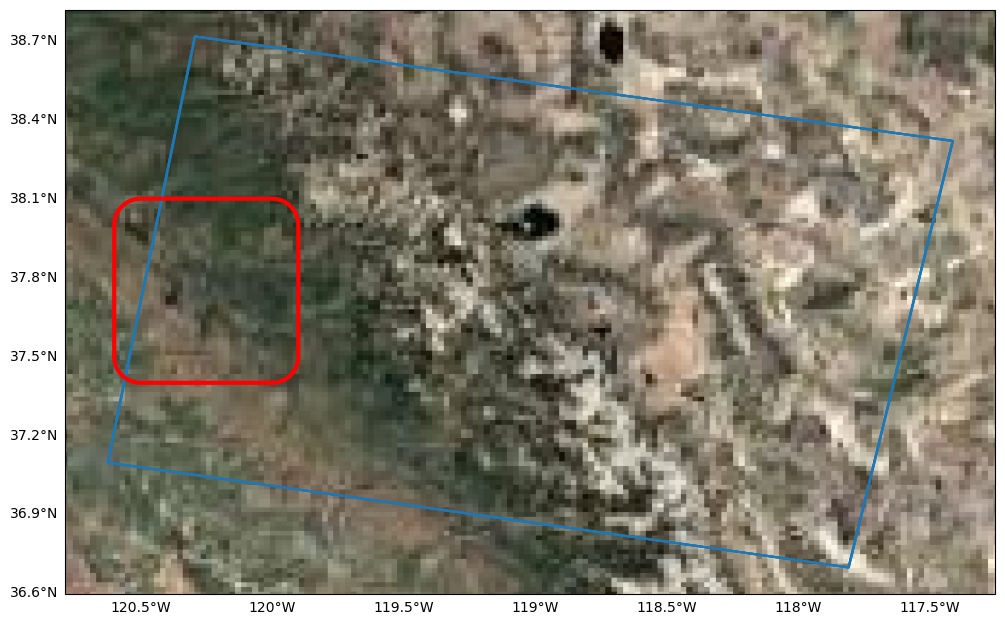

In [49]:
# Plot the results
fig, ax = plt.subplots(1, figsize=[12,8], subplot_kw=dict(projection=ccrs.PlateCarree()))
image = cimgt.GoogleTiles(url = 'https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}')
ax.add_image(image, 6, cmap='gray', zorder=0)
gdfs.exterior.plot(ax=ax)
ax.plot(aoi_polygon.exterior.xy[0], aoi_polygon.exterior.xy[1], 'r-', linewidth=3)
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False


In [ ]:
# Download the SLCs, or you can download them manually from ASF Search if you have an account
search_results.download(
     path = str(slc_dir), 
     processes = n_processes
  )

/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/asf_search/download/download.py:66: UserWarning: File already exists, skipping download: /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/data/S1A_IW_SLC__1SDV_20230314T135953_20230314T140020_047641_05B8CA_C206.zip
  warnings.warn(f'File already exists, skipping download: {os.path.join(path, filename)}')
/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/asf_search/download/download.py:66: UserWarning: File already exists, skipping download: /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/data/S1A_IW_SLC__1SDV_20230302T135953_20230302T140020_047466_05B2DB_165C.zip
  warnings.warn(f'File already exists, skipping download: {os.path.join(path, filename)}')
/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/asf_search/download/download.py:66: UserWarning: File already exists, skipping download: /home/erickleon/Desktop/insa

## Download DEM
https://github.com/ACCESS-Cloud-Based-InSAR/dem-stitcher

In [17]:
download_dem_for_isce2(extent=[aoi[2], aoi[0], aoi[3], aoi[1]],
                       dem_name=dem_name,
                       dem_dir=dem_dir,
                       buffer=0.5)

Reading tile metadata:   0%|          | 0/4 [00:00<?, ?it/s]/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/dem_stitcher/rio_window.py:144: RuntimeWarning: Requesting extent beyond raster bounds of [-121.00013888888888, 37.00013888888889, -120.00013888888888, 38.00013888888889]. Shrinking bounds in raster crs to (-121.0, 37.00013888888889, -120.00013888888888, 38.00013888888889).
  warn(
/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/dem_stitcher/rio_window.py:144: RuntimeWarning: Requesting extent beyond raster bounds of [-121.00013888888888, 38.00013888888889, -120.00013888888888, 39.00013888888889]. Shrinking bounds in raster crs to (-121.0, 38.00013888888889, -120.00013888888888, 39.0).
  warn(
Reading tile imagery: 100%|██████████| 4/4 [03:24<00:00, 51.13s/it] 


/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DEM/full_res.dem.wgs84
fixing xml file path for file: /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DEM/full_res.dem.wgs84
Writing geotrans to VRT for /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DEM/full_res.dem.wgs84
/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/isce/applications/fixImageXml.py -i /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DEM/full_res.dem.wgs84.xml --full


'/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DEM/full_res.dem.wgs84.xml'

## Download ORBIT
https://github.com/scottstanie/sentineleof/blob/master/eof/download.py

In [ ]:
# eof = Earth Observation Finder, a module to download auxiliary files for Sentinel-1 SLCs
eof.download.main(search_path=slc_dir, save_dir=orbit_dir)

[]

## AUX DATA
https://aux.sentinel1.eo.esa.int/

In [19]:
## NEED TO VERIFY THAT AUX_DATA ARE INGESTED CORRECTLY WITH STACKSENTINEL

url = 'https://sar-mpc.eu/adf/aux_cal/?adf__active=True'
response = requests.get(url)
response.raise_for_status()
page_content = response.text

file_urls = []
file_names = []
start_marker = '<a href="'
end_marker = '</a>'
start_index = page_content.find(start_marker)
while start_index != -1:
    end_index = page_content.find(end_marker, start_index + len(start_marker))
    file_url = page_content[start_index + len(start_marker):end_index]
    if file_url.startswith('/download'):
        file_urls.append(file_url.split('">')[0])
        file_names.append(file_url.split('">')[1])
    start_index = page_content.find(start_marker, end_index)

# Download
for file_name, file_url in zip(file_names, file_urls):
    file_path = aux_dir / file_name
    file_path = file_path.with_suffix('.zip')

    if file_path.exists() or file_path.stem + '.SAFE':
        print(f'SKIP \033[1m{file_path.stem}\033[0m exists')
    else:
        response = requests.get(urljoin(url, file_url))
        response.raise_for_status()
        file_path.write_bytes(response.content)
        
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(aux_dir)
        file_path.unlink()
        print(f"Downloaded: {file_name}")

SKIP S1D_AUX_CAL_V20260319T000000_G20260415T150219 exists
SKIP S1D_AUX_CAL_V20251110T000000_G20260415T150006 exists
SKIP S1D_AUX_CAL_V20251104T000000_G20251029T104006 exists
SKIP S1C_AUX_CAL_V20250427T000000_G20260212T132118 exists
SKIP S1C_AUX_CAL_V20250427T000000_G20260203T150545 exists
SKIP S1C_AUX_CAL_V20250325T000000_G20251015T082613 exists
SKIP S1C_AUX_CAL_V20250224T000000_G20250519T123501 exists
SKIP S1C_AUX_CAL_V20250101T000000_G20250522T094222 exists
SKIP S1C_AUX_CAL_V20250101T000000_G20250522T094138 exists
SKIP S1C_AUX_CAL_V20241204T000000_G20250522T094033 exists
SKIP S1B_AUX_CAL_V20190514T090000_G20251216T112346 exists
SKIP S1A_AUX_CAL_V20190228T092500_G20240327T102320 exists
SKIP S1A_AUX_CAL_V20171017T080000_G20240327T102202 exists
SKIP S1A_AUX_CAL_V20160627T000000_G20240327T102007 exists
SKIP S1B_AUX_CAL_V20160422T000000_G20251216T112140 exists
SKIP S1A_AUX_CAL_V20150722T120000_G20240327T101830 exists
SKIP S1A_AUX_CAL_V20150519T120000_G20240327T101700 exists
SKIP S1A_AUX_C

# Stack Sentinel - make coregistrated SLC stack

In [20]:
# # We need to add isce2/contrib/stack/ directory to our PATH env variable
# isce2_stack_dir = Path('/home/erickleon/tools/isce22/src/isce2/contrib/stack')
# os.environ['PATH'] += (':' + str(isce2_stack_dir / 'topsStack'))
# # os.environ['PYTHONPATH'] = str(isce2_stack_dir) 
# os.environ['PYTHONPATH'] = str(isce2_stack_dir) + ':' + os.environ.get('PYTHONPATH', '')

# # Go to work_dir processing directory
# os.chdir(isce_run_dir)
# print(f'Work directory; {os.getcwd()}')

# Stack Sentinel - make coregistrated SLC stack
import sys
from pathlib import Path

# Detecta automáticamente la ruta según el entorno conda activo
conda_prefix = Path(sys.prefix)
isce2_stack_dir = conda_prefix / 'share/isce2'

os.environ['PATH'] += ':' + str(isce2_stack_dir / 'topsStack')
os.environ['PYTHONPATH'] = str(isce2_stack_dir) + ':' + os.environ.get('PYTHONPATH', '')

# Verifica ambas rutas
result = subprocess.run('which stackSentinel.py', shell=True, capture_output=True, text=True)
print(f"stackSentinel.py: {result.stdout.strip()}")
print(f"PYTHONPATH: {os.environ['PYTHONPATH']}")

os.chdir(isce_run_dir)
print(f'Work directory: {os.getcwd()}')

stackSentinel.py: /home/erickleon/miniconda3/envs/isce2-fresh/share/isce2/topsStack/stackSentinel.py
PYTHONPATH: /home/erickleon/miniconda3/envs/isce2-fresh/share/isce2:
Work directory: /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce


In [21]:
# Generate config and run file for generation of coregistrated SLCs

processing_bound = ' '.join(str(x) for x in aoi) # SNWE
args = f'stackSentinel.py -s {slc_dir} -d {dem_path} -b "{processing_bound}" -a {aux_dir} -o {orbit_dir} -C NESD  -W slc'
args += ' --num_proc4topo 10 --num_proc 10' # to add multi threading
print(args)

# Creates configs and run_files
subprocess.run(args, shell=True, close_fds=True)

# List created run files
run_files = list(run_dir.glob('run_*'))
print(f'Number of run files: {len(run_files)}')
run_files

stackSentinel.py -s /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/data -d /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DEM/full_res.dem.wgs84 -b "37.5 38 -120.5 -120" -a /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/AUX -o /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/ORBIT -C NESD  -W slc --num_proc4topo 10 --num_proc 10

**************************
run_files folder exists.
/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files  already exists.
Please remove or rename this folder and try again.

**************************
Number of run files: 13


[PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_01_unpack_topo_reference'),
 PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_02_unpack_secondary_slc'),
 PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_03_average_baseline'),
 PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_04_extract_burst_overlaps'),
 PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_05_overlap_geo2rdr'),
 PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_06_overlap_resample'),
 PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_07_pairs_misreg'),
 PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/

In [22]:
print(f"isce2_stack_dir existe: {isce2_stack_dir.exists()}")
print(f"topsStack existe: {(isce2_stack_dir / 'topsStack').exists()}")
print(f"stackSentinel.py existe: {(isce2_stack_dir / 'topsStack/stackSentinel.py').exists()}")
#  ¿Existe run_dir y qué contiene?
print(f"run_dir: {run_dir}")
print(f"Existe: {run_dir.exists()}")
print(f"Archivos: {list(run_dir.glob('*'))}")

isce2_stack_dir existe: True
topsStack existe: True
stackSentinel.py existe: True
run_dir: /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files
Existe: True
Archivos: [PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_01_unpack_topo_reference'), PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_02_unpack_secondary_slc'), PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_03_average_baseline'), PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_04_extract_burst_overlaps'), PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_05_overlap_geo2rdr'), PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_06_overlap_resample'), PosixPath('/h

In [23]:
# Step 1 - unpack_topo_reference
# Directory: reference and geom_reference
run_file = list(run_dir.glob('run_01*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_01_unpack_topo_reference!


/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Completed Parsing the Configuration file
Functions to be executed:
['Function-1', 'Function-2']
Running: Sentinel1_TOPS
['--dirname', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/data/S1A_IW_SLC__1SDV_20230206T135954_20230206T140020_047116_05A706_874E.zip', '--swaths', '1 2 3', '--orbitdir', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/ORBIT', '--outdir', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference', '--auxdir', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/AUX', '--bbox', '37.5 38 -120.5 -120', '--pol', 'vv']
Input XML files:  ['/vsizip//home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/data/S1A_IW_SLC__1SDV_20230206T135954_20230206T140020_047116_05A706_874E.zip/S1A_IW_SLC__1SDV_20230206T135954_20230206T140020_047116_05A706_874E.SAFE/annotation/s1a-iw1-slc-vv-20230206t135954-20230206t140020-047116-05a706-004.xml']
Input TIFF files:  ['/vsiz

In [24]:
# Step 2
# Directory: secondarys 
run_file = list(run_dir.glob('run_02*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_02_unpack_secondary_slc!


/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Running: Sentinel1_TOPS
['--dirname', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/data/S1A_IW_SLC__1SDV_20230218T135953_20230218T140020_047291_05ACF0_56E4.zip', '--swaths', '1 2 3', '--orbitdir', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/ORBIT', '--outdir', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/secondarys/20230218', '--auxdir', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/AUX', '--bbox', '37.5 38 -120.5 -120', '--pol', 'vv']
Running: Sentinel1_TOPS
['--dirname', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/data/S1A_IW_SLC__1SDV_20230314T135953_20230314T140020_047641_05B8CA_C206.zip', '--swath

In [25]:
# Step 3 average baseline
# Directory: baselines
run_file = list(run_dir.glob('run_03*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_03_average_baseline!
Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Running: computeBaseline
['--reference', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference/', '--secondary', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/secondarys/20230218', '--baseline_file', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/baselines/20230206_20230218/20230206_20230218.txt']
Running: computeBaseline
['--reference', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference/', '--secondary', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/

In [26]:
# Step 4 extract_burst_overlaps
# Directory: reference/overlap
run_file = list(run_dir.glob('run_04*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)

out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_04_extract_burst_overlaps!
Overlap 0 start time - IW-3 2023-02-06 14:00:05.053729 subset
Overlap 0 stop time - IW-3 2023-02-06 14:00:05.413451 subset
Overlap 0 number of lines - IW-3 176 subset
Overlap 0 number of valid lines - IW-3 122 subset
Top:  ['/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference/overlap/IW3/burst_top_01_02.slc']
Bottom:  ['/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference/overlap/IW3/burst_bot_01_02.slc']
Overlap 1 start time - IW-3 2023-02-06 14:00:07.812286 subset
Overlap 1 stop time - IW-3 2023-02-06 14:00:08.169952 subset
Overlap 1 number of lines - IW-3 175 subset
Overlap 1 number of valid lines - IW-3 122 subset
Top:  ['/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference/overlap/IW3/burst_top_01_02.slc', '/home/erickleon/Desktop/insar/isce2_t

In [27]:
# Step 5 overlap_geo2rdr
# Directory: coreg_secondarys
run_file = list(run_dir.glob('run_05*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_05_overlap_geo2rdr!
Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Running: geo2rdr
Running: geo2rdr
['--secondary', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/secondarys/20230302', '--reference', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference', '--geom_referenceDir', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/geom_reference', '--coregSLCdir', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/coreg_secondarys/20230302', '--overlap']
['--secondary', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/secondarys/202

In [28]:
# Step 6 overlap_resample
# Directory: coreg_secondarys
run_file = list(run_dir.glob('run_06*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_06_overlap_resample!
Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Running: resamp_withCarrier
['--secondary', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/secondarys/20230314', '--reference', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference', '--coregdir', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/coreg_secondarys/20230314', '--overlap']
Running: resamp_withCarrier
['--secondary', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/secondarys/20230218', '--reference', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference', '--coregdir', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_ne

In [29]:
# Step 7 pairs_misreg
# Directory: ESD 
run_file = list(run_dir.glob('run_07*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_07_pairs_misreg!


/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptio

Completed Parsing the Configuration file
Functions to be executed:
['Function-1', 'Function-2', 'Function-3', 'Function-4']
Completed Parsing the Configuration file
Functions to be executed:
['Function-1', 'Function-2', 'Function-3', 'Function-4']
Running: generateIgram
['--reference', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference', '--secondary', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/coreg_secondarys/20230302', '--interferogram', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/coarse_interferograms/20230206_20230302', '--interferogram_prefix', 'int', '--overlap']
Running: generateIgram
['--reference', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/coreg_secondarys/20230302', '--secondary', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/coreg_secondarys/20230314', '--interferogram', '/home/erickleon/

In [30]:
# Step 8 pairs_misreg
# Directory: timeseries_misreg
run_file = list(run_dir.glob('run_08*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_08_timeseries_misreg!

Rank of design matrix: 3
Design matrix is full rank.
RMSE : 0.0007700353844631683 pixels

Estimated offsets with respect to the stack reference date

20230206 : 0.0
20230218 : 0.0022975604472653304
20230302 : 0.0013820900033245593
20230314 : -9.418008547626856e-05


Rank of design matrix: 3
Design matrix is full rank.
RMSE : 0.01819970402121377 pixels

Estimated offsets with respect to the stack reference date

20230206 : 0.0
20230218 : -0.01819970456360684
20230302 : 0.009099852281803524
20230314 : 0.15469748879065878


STEP FINISHED - SUCESS!!!


In [31]:
# Step 9 pairs_misreg
# Directory: fullBurst_geo2rdr!
run_file = list(run_dir.glob('run_09*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_09_fullBurst_geo2rdr!
Completed Parsing the Configuration fileCompleted Parsing the Configuration file
Completed Parsing the Configuration file

Functions to be executed:Functions to be executed:

Functions to be executed:
['Function-1']['Function-1']

['Function-1']
Running: geo2rdr
['--secondary', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/secondarys/20230218', '--reference', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference', '--geom_referenceDir', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/geom_reference', '--coregSLCdir', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/coreg_secondarys/20230218', '--azimuth_misreg', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/misreg/azimuth/dates/20230218.txt', '-

In [32]:
# Step 10 pairs_misreg
# Directory: fullBurst_resample!
run_file = list(run_dir.glob('run_10*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_10_fullBurst_resample!
Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Completed Parsing the Configuration fileCompleted Parsing the Configuration file

Functions to be executed:Functions to be executed:

['Function-1']['Function-1']

Running: resamp_withCarrier
['--secondary', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/secondarys/20230302', '--reference', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference', '--coregdir', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/coreg_secondarys/20230302', '--azimuth_misreg', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/misreg/azimuth/dates/20230302.txt', '--range_misreg', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/misreg/range/da

In [33]:
# Step 11 pairs_misreg
# Directory: extract_stack_valid_region'
run_file = list(run_dir.glob('run_11*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_11_extract_stack_valid_region!
creating  /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/stack
checking the number of bursts in coreg_secondarys against the one in reference
all secondary images have the same number of bursts as the reference
******************
swath:  3
/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/coreg_secondarys/20230218
minSecondary,maxSecondary 1 5
minReference,maxReference 1 5
minBurst, maxBurst:  1 5
/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/coreg_secondarys/20230302
minSecondary,maxSecondary 1 5
minReference,maxReference 1 5
minBurst, maxBurst:  1 5
/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/coreg_secondarys/20230314
minSecondary,maxSecondary 1 5
minReference,maxReference 1 5
minBurst, maxBurst:  1 5
writing  /home/erickl

In [34]:
# Step 12 pairs_misreg
# Directory: merge_reference_secondary_slc
run_file = list(run_dir.glob('run_12*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_12_merge_reference_secondary_slc!


/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptio

Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Running: mergeBursts
['--stack', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/stack', '--inp_reference', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference', '--dirname', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference', '--name_pattern', 'burst*slc', '--outfile', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/merged/SLC/20230206/20230206.slc', '--method', 'top', '--valid_only', '--range_looks', '9', '--azimuth_looks', '3']
Updating the valid region of each burst to the common valid region of the stack
bursts:  1 5
writing merged file to disk via gdal.Translate ...
00...10...20...30...41...50...60...70...80...91...100 
Skipping multi-looking ....
Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Running: mergeBursts
['--sta

In [35]:
# Step 13 pairs_misreg
# Directory: grid_baseline
run_file = list(run_dir.glob('run_13*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_files/run_13_grid_baseline!
Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Running: baselineGrid
['--reference', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference/', '--secondary', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/secondarys/20230218', '--baseline_file', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/merged/baselines/20230218/20230218']
Baseline file /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/merged/baselines/20230218/20230218 dims: 15L x 9P
Polynomial Order: 0 - by - 0 
0	
Polynomial Order: 0 - by - 0 
0	
Polynomial Order: 0 - by - 0 
0	
Polynomial Order: 0 - by - 0 
0	
Polynomial Order: 0 - by - 0 
0	
Polynomial Order: 0 - by - 0 
0	
Polynomial Order: 0 - by - 0 
0	
Polynomial Order: 0 - by - 0 
0	
Pol

# Generate interferograms


In [36]:
download_file = isce2_stack_dir / 'topsStack/interferogramStack.py'
url = 'https://raw.githubusercontent.com/mgovorcin/isce2_topsStack_ifg_network/main/interferogramStack.py'
filename, headers = urllib.request.urlretrieve(url, filename=str(download_file))

download_file.chmod(33791)
subprocess.run(f'interferogramStack.py -h', shell=True)

usage: interferogramStack.py [-h] [-H] -s WORK_DIR [-n NETWORK]
                             [-c NUM_CONNECTIONS]
                             [-p PERIODIC_CONNECTIONS [PERIODIC_CONNECTIONS ...]]
                             [-pt PERIODIC_TOLERANCE]
                             [-sr SINGLE_REFERENCE_DATE]
                             [--start_date STARTDATE] [--end_date ENDDATE]
                             [--max_bperp MAX_BPERP] [--max_btemp MAX_BTEMP]
                             [-z AZIMUTHLOOKS] [-r RANGELOOKS]
                             [-f FILTSTRENGTH] [-useGPU]
                             [--num_proc NUMPROCESS] [-u {icu,snaphu}]
                             [-rmFilter] [-t TEXT_CMD] [--force]

Prepare the directory structure and config files for interferogram stack
processing of Sentinel data

options:
  -h, --help            show this help message and exit
  -H, --hh              Display detailed help information.
  -s WORK_DIR, --stack_directory WORK_DIR
                

CompletedProcess(args='interferogramStack.py -h', returncode=0)

In [37]:
ifg_args = dict(
            network = 'sequential',       # [single_reference, sequential, delaunay, full]
            num_connections = 1,          # connection number of interferograms between each date for sequential network
            periodic_connections = None,  # number of periodic interferograms in days [180, 365], str or list
            periodic_tolerance = 1,       # tolerance for selection of periodic interferograms around the defined period
            single_reference_date = None, # reference date for single reference network, e.g. 2015-01-23
            start_date = None,            # Start date for interferogram network generation, e.g. 2015-01-23
            end_date = None,              # End date for interferogram network generation, e.g. 2015-01-23
            max_bperp = None,             # Threshold for Maximum Perpendicular baseline [in meters]
            max_btemp = None,             # Threshold for Maximum Temporal baseline [in days]
            azimuth_looks = 3,            # Number of looks in azimuth for interferogram multi-looking
            range_looks = 9,              # Number of looks in range for interferogram multi-looking
            filter_strength = 0.5,        # Filter strength for interferogram filtering
            unw_method = 'snaphu',        # Unwrapping method
            force = True                  # Overwrite run files directory
            )

ifg_cmd_params = dict(
            network = '-n',       
            num_connections = '-c',         
            periodic_connections = '-p',  
            periodic_tolerance = '-pt',       
            single_reference_date = '-sr', 
            start_date = '--start_date',           
            end_date = '--end_date',              
            max_bperp = '--max_bperp',             
            max_btemp = '--max_btemp',            
            azimuth_looks = '-z',           
            range_looks = '-r',             
            filter_strength = '-f',        
            unw_method = '-u',        
            force = '--force'                  
            )

ifg_args

{'network': 'sequential',
 'num_connections': 1,
 'periodic_connections': None,
 'periodic_tolerance': 1,
 'single_reference_date': None,
 'start_date': None,
 'end_date': None,
 'max_bperp': None,
 'max_btemp': None,
 'azimuth_looks': 3,
 'range_looks': 9,
 'filter_strength': 0.5,
 'unw_method': 'snaphu',
 'force': True}

In [38]:
cmd = f'interferogramStack.py -s {isce_run_dir}'
for arg in ifg_args.keys():
    if ifg_args[arg]:
        if arg == 'force':
            cmd +=  ' ' + ifg_cmd_params[arg]
        else:
            cmd +=  ' ' + ifg_cmd_params[arg] + ' ' + str(ifg_args[arg])

print(cmd)
subprocess.run(cmd, shell=True)
display.Image(f'{isce_run_dir}/interferogram_network.png',width=1000, height=1000)

# List the run files
run_files = list(run_ifg_dir.glob('run_*'))
print(f'Number of run files: {len(run_files)}')
run_files

interferogramStack.py -s /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce -n sequential -c 1 -pt 1 -z 3 -r 9 -f 0.5 -u snaphu --force


/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


False
2026-05-21 14:44:43,834 - matplotlib - DEBUG - matplotlib data path: /home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/matplotlib/mpl-data
2026-05-21 14:44:43,838 - matplotlib - DEBUG - CONFIGDIR=/home/erickleon/.var/app/com.visualstudio.code/config/matplotlib
2026-05-21 14:44:43,868 - matplotlib - DEBUG - interactive is False
2026-05-21 14:44:43,868 - matplotlib - DEBUG - platform is linux
2026-05-21 14:44:43,903 - matplotlib - DEBUG - CACHEDIR=/home/erickleon/.var/app/com.visualstudio.code/cache/matplotlib
2026-05-21 14:44:43,904 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/erickleon/.var/app/com.visualstudio.code/cache/matplotlib/fontlist-v390.json
2026-05-21 14:44:44,069 - matplotlib.pyplot - DEBUG - Loaded backend Agg version v2.2.
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

Selected pairs (# 3): 

('20230206', '20230218')
('20230218', '20230302')
('20230302', '20230314')
writing  /home/erickleon/Desktop/insar/isce2_topsStack_ifg_netwo

[PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_ifg_files/run_21_generate_burst_igram'),
 PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_ifg_files/run_22_merge_burst_igram'),
 PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_ifg_files/run_23_filter_coherence'),
 PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_ifg_files/run_24_unwrap')]

In [39]:
# Step 21 
# Directory: generate_burst_igram!
run_file = list(run_ifg_dir.glob('run_21*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_ifg_files/run_21_generate_burst_igram!


/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Running: generateIgram
['--reference', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference', '--secondary', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/coreg_secondarys/20230218', '--interferogram', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/interferograms/20230206_20230218', '--interferogram_prefix', 'fine']
minSecondary,maxSecondary 1 5
minReference,maxReference 1 5
minBurst, maxBurst:  1 5
matching burst numbers:  1 1
multiply
read
No range offsets provided
matching burst numbers:  2 2
multiply
read
No range offsets provided
matching burst numbers:  3 3
multiply
read
No range offsets provided
matching burst numbers:  4 4
multiply
read
No range offsets provided
matching burst numbers:  5 5
multiply
read
No range offsets provided
Type:  <class 'isceobj.Sensor.TOPS.TOPSSwathSLCProduct.TOPSSwat

In [40]:
# Step 22
# Directory: _merge_burst_igram!
run_file = list(run_ifg_dir.glob('run_22*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_ifg_files/run_22_merge_burst_igram!
Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Running: mergeBursts
['--stack', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/stack', '--inp_reference', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/interferograms/20230206_20230218', '--dirname', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/interferograms/20230206_20230218', '--name_pattern', 'fine*int', '--outfile', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/merged/interferograms/20230206_20230218/fine.int', '--method', 'top', '--aligned', '--valid_only', '--use_virtual_files', '--multilook', '--range_looks', '9', '--azimuth_looks', '3']
Updating the valid region of each burst to the common valid region of the stack
bursts:  1 5
mult

In [41]:
# Step 23
# Directory: filter_coherence!
run_file = list(run_ifg_dir.glob('run_23*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_ifg_files/run_23_filter_coherence!


line:  2293

Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Running: FilterAndCoherence
['--input', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/merged/interferograms/20230206_20230218/fine.int', '--filt', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/merged/interferograms/20230206_20230218/filt_fine.int', '--coh', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/merged/interferograms/20230206_20230218/filt_fine.cor', '--strength', '0.5', '--slc1', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/merged/SLC/20230206/20230206.slc.full', '--slc2', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/merged/SLC/20230218/20230218.slc.full', '--complex_coh', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/merged/interferograms/20230206_20230218/fine.cor', '--range_looks', '9',

In [42]:
# Step 24
# Directory: coarse_interferograms
run_file = list(run_ifg_dir.glob('run_24*'))[0]
print(f'RUNNING {run_file}!')
run_file.chmod(33791)
out = subprocess.run(str(run_file), shell=True, check=True, stdout=subprocess.PIPE, close_fds=True)
print(out.stdout.decode("utf-8"))
print('STEP FINISHED - SUCESS!!!' if  out.returncode == 0 else 'STEP FINISHED - FAILED!!!')

RUNNING /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_ifg_files/run_24_unwrap!
Completed Parsing the Configuration file
Functions to be executed:
['Function-1']
Running: unwrap
['--ifg', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/merged/interferograms/20230206_20230218/filt_fine.int', '--unw', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/merged/interferograms/20230206_20230218/filt_fine.unw', '--coh', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/merged/interferograms/20230206_20230218/filt_fine.cor', '--reference', '/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/reference', '--defomax', '2', '--rlks', '9', '--alks', '3', '--method', 'snaphu']
unwrapping method :  snaphu

snaphu v1.4.2
Reading wrapped phase from file /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/merged/interf

# Process more interferograms

In [43]:
# Lets change network to delaunay
ifg_args['network'] = 'delaunay'

In [44]:
cmd = f'interferogramStack.py -s {isce_run_dir}'
for arg in ifg_args.keys():
    if ifg_args[arg]:
        if arg == 'force':
            cmd +=  ' ' + ifg_cmd_params[arg]
        else:
            cmd +=  ' ' + ifg_cmd_params[arg] + ' ' + str(ifg_args[arg])

print(cmd)
subprocess.run(cmd, shell=True)

# List the run files
run_files = list(run_ifg_dir.glob('run_*'))
print(f'Number of run files: {len(run_files)}')
run_files

interferogramStack.py -s /home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce -n delaunay -c 1 -pt 1 -z 3 -r 9 -f 0.5 -u snaphu --force

**************************
run_ifg_files folder exists.
/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_ifg_files  already exists.
Deleting all existing run_files in this folder.

**************************


/home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


True
2026-05-21 15:02:35,212 - matplotlib - DEBUG - matplotlib data path: /home/erickleon/miniconda3/envs/isce2-fresh/lib/python3.11/site-packages/matplotlib/mpl-data
2026-05-21 15:02:35,218 - matplotlib - DEBUG - CONFIGDIR=/home/erickleon/.var/app/com.visualstudio.code/config/matplotlib
2026-05-21 15:02:35,240 - matplotlib - DEBUG - interactive is False
2026-05-21 15:02:35,241 - matplotlib - DEBUG - platform is linux
2026-05-21 15:02:35,275 - matplotlib - DEBUG - CACHEDIR=/home/erickleon/.var/app/com.visualstudio.code/cache/matplotlib
2026-05-21 15:02:35,277 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/erickleon/.var/app/com.visualstudio.code/cache/matplotlib/fontlist-v390.json
2026-05-21 15:02:35,506 - matplotlib.pyplot - DEBUG - Loaded backend Agg version v2.2.

Updating an existing interferogram stack ...

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

Existing pairs in the interferogram stack (# 3): 

('20230206', '20230218')
('20230218', '20230302')
('20230302', '20

[PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_ifg_files/run_21_generate_burst_igram'),
 PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_ifg_files/run_22_merge_burst_igram'),
 PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_ifg_files/run_23_filter_coherence'),
 PosixPath('/home/erickleon/Desktop/insar/isce2_topsStack_ifg_network/test_run/DSC/144/isce/run_ifg_files/run_24_unwrap')]

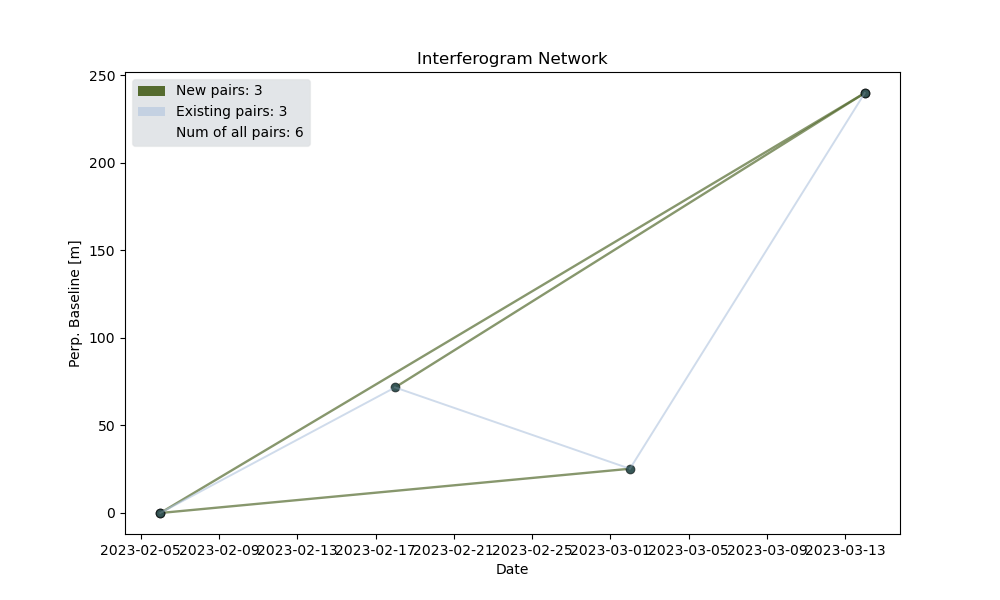

In [45]:
display.Image(f'{isce_run_dir}/interferogram_network.png',width=500, height=500)